# Classificação de Feijões (Dry Bean Dataset) com KNN

Este notebook apresenta a solução para o problema de classificação multiclasse do dataset **Dry Bean**, utilizando o algoritmo **K-Nearest Neighbors (KNN)**.

### Objetivo:
Classificar 7 diferentes tipos de feijões secos com base em características morfológicas (área, perímetro, compacidade, etc.).

### Abordagem:
1. **Exploração de Dados**: Entender as classes e características.
2. **Pré-processamento**: Normalização (Z-score) e divisão dos dados.
3. **Implementação Manual**: KNN desenvolvido do zero para fins educacionais.
4. **Implementação Sklearn**: Uso da biblioteca padrão para comparação.
5. **Avaliação**: Acurácia e Matriz de Confusão.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Configurações de visualização
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Carregamento e Exploração dos Dados

In [2]:
# Carregando o dataset baixado anteriormente
file_path = 'DryBeanDataset/Dry_Bean_Dataset.xlsx'
df = pd.read_excel(file_path)

print(f"Formato do dataset: {df.shape}")
df.head()

Formato do dataset: (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


/tmp/ipykernel_16303/3719759170.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='viridis')


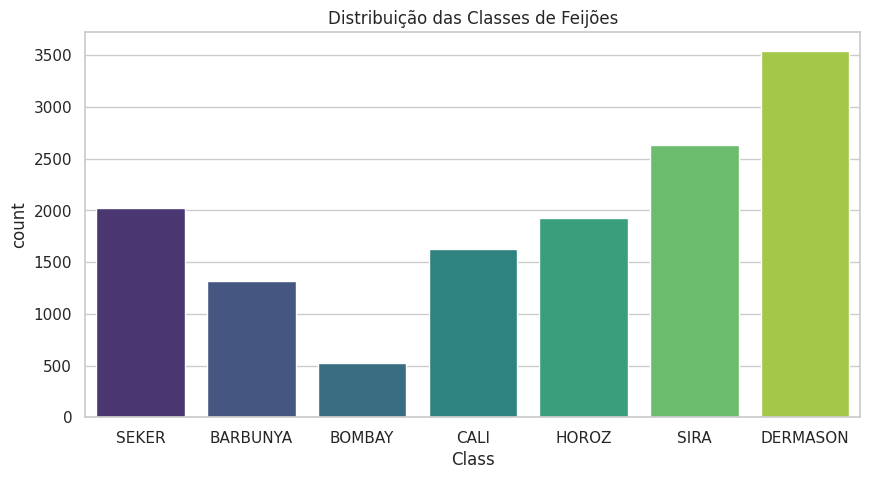

,count,mean,std,min,25%,50%,75%,max
Area,13611.0,53048.284549,29324.095717,20420.000000,36328.000000,44652.000000,61332.000000,254616.000000
Perimeter,13611.0,855.283459,214.289696,524.736000,703.523500,794.941000,977.213000,1985.370000
MajorAxisLength,13611.0,320.141867,85.694186,183.601165,253.303633,296.883367,376.495012,738.860153
MinorAxisLength,13611.0,202.270714,44.970091,122.512653,175.848170,192.431733,217.031741,460.198497
AspectRation,13611.0,1.583242,0.246678,1.024868,1.432307,1.551124,1.707109,2.430306
Eccentricity,13611.0,0.750895,0.092002,0.218951,0.715928,0.764441,0.810466,0.911423
ConvexArea,13611.0,53768.200206,29774.915817,20684.000000,36714.500000,45178.000000,62294.000000,263261.000000
EquivDiameter,13611.0,253.064220,59.177120,161.243764,215.068003,238.438026,279.446467,569.374358
Extent,13611.0,0.749733,0.049086,0.555315,0.718634,0.759859,0.786851,0.866195
Solidity,13611.0,0.987143,0.004660,0.919246,0.985670,0.988283,0.990013,0.994677


In [3]:
# Verificando a distribuição das classes
plt.figure(figsize=(10, 5))
sns.countplot(x='Class', data=df, palette='viridis')
plt.title('Distribuição das Classes de Feijões')
plt.show()

# Estatísticas básicas
df.describe().T

## 2. Pré-processamento

O KNN é baseado em distância euclidiana, por isso é fundamental que todos os atributos estejam na mesma escala.

In [4]:
# Separando features (X) e target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# Codificando as classes (String -> Numérico)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Divisão em Treino (70%), Validação (15%) e Teste (15%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y_encoded, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Normalização (Z-score)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Treino: {X_train_scaled.shape}, Validação: {X_val_scaled.shape}, Teste: {X_test_scaled.shape}")

Treino: (9527, 16), Validação: (2042, 16), Teste: (2042, 16)


## 3. Implementação Manual do KNN (Multiclasse)

Vamos implementar a lógica do KNN passo a passo.

In [5]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b)**2, axis=1))

def predict_knn(X_train, y_train, X_query, k):
    y_pred = []
    for x_q in X_query:
        # 1. Calcular distâncias entre o ponto de consulta e todos os pontos de treino
        distances = euclidean_distance(X_train, x_q)
        
        # 2. Obter os índices dos k vizinhos mais próximos
        k_indices = np.argsort(distances)[:k]
        
        # 3. Obter os rótulos desses k vizinhos
        k_nearest_labels = y_train[k_indices]
        
        # 4. Votação majoritária (Multiclasse)
        counts = np.bincount(k_nearest_labels)
        y_pred.append(np.argmax(counts))
        
    return np.array(y_pred)

# Testando com k=5 no conjunto de validação (pequena amostra para velocidade)
print("Executando predição manual...")
sample_size = 500 # Usando amostra para demonstração rápida
y_val_pred_manual = predict_knn(X_train_scaled, y_train, X_val_scaled[:sample_size], k=5)
acc_manual = accuracy_score(y_val[:sample_size], y_val_pred_manual)
print(f"Acurácia Manual (k=5) na amostra de validação: {acc_manual:.4f}")

Executando predição manual...
Acurácia Manual (k=5) na amostra de validação: 0.9200


## 4. Otimização do Hiperparametro K

Vamos testar diferentes valores de K para encontrar o melhor desempenho.

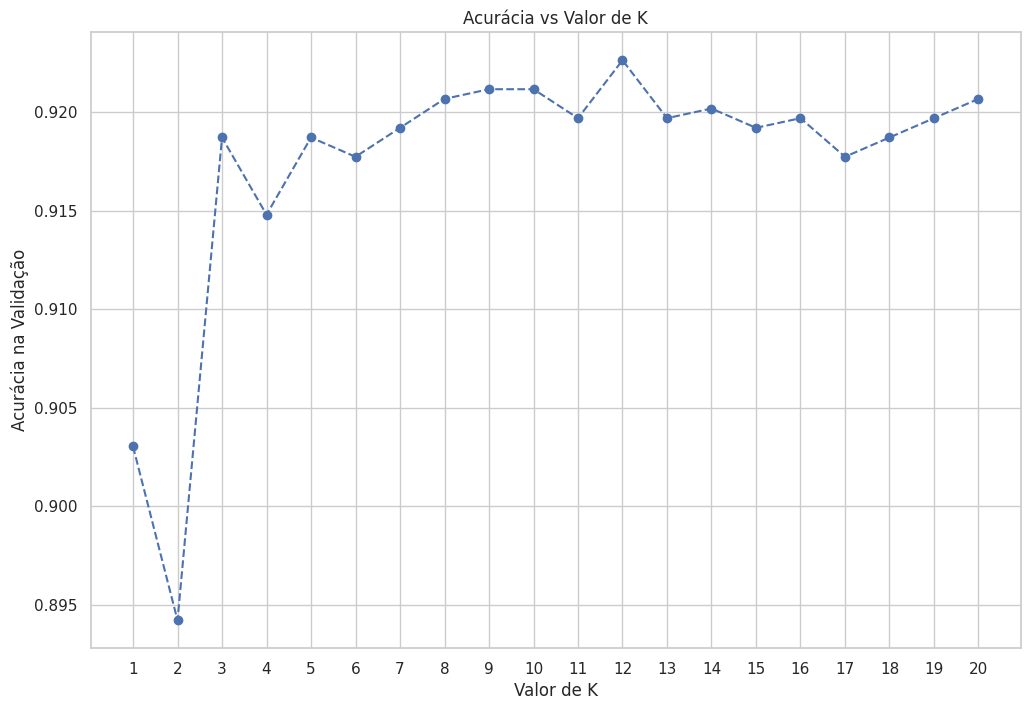

O melhor valor de K encontrado foi: 12


In [6]:
k_range = range(1, 21)
accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_val_pred = knn.predict(X_val_scaled)
    accuracies.append(accuracy_score(y_val, y_val_pred))

plt.plot(k_range, accuracies, marker='o', linestyle='--', color='b')
plt.title('Acurácia vs Valor de K')
plt.xlabel('Valor de K')
plt.ylabel('Acurácia na Validação')
plt.xticks(k_range)
plt.show()

best_k = k_range[np.argmax(accuracies)]
print(f"O melhor valor de K encontrado foi: {best_k}")

## 5. Modelo Final (Scikit-Learn)

Utilizaremos o melhor K encontrado para avaliar o modelo no conjunto de **Teste** (dados nunca vistos).

In [7]:
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)

y_test_pred = final_knn.predict(X_test_scaled)
final_acc = accuracy_score(y_test, y_test_pred)

print(f"Acurácia Final no Conjunto de Teste: {final_acc:.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_test_pred, target_names=le.classes_))

Acurácia Final no Conjunto de Teste: 0.9285

Relatório de Classificação:
              precision    recall  f1-score   support

    BARBUNYA       0.96      0.92      0.94       198
      BOMBAY       1.00      1.00      1.00        78
        CALI       0.92      0.95      0.94       239
    DERMASON       0.90      0.92      0.91       509
       HOROZ       0.98      0.94      0.96       301
       SEKER       0.96      0.95      0.96       323
        SIRA       0.88      0.88      0.88       394

    accuracy                           0.93      2042
   macro avg       0.94      0.94      0.94      2042
weighted avg       0.93      0.93      0.93      2042



## 6. Visualização dos Resultados (Matriz de Confusão)

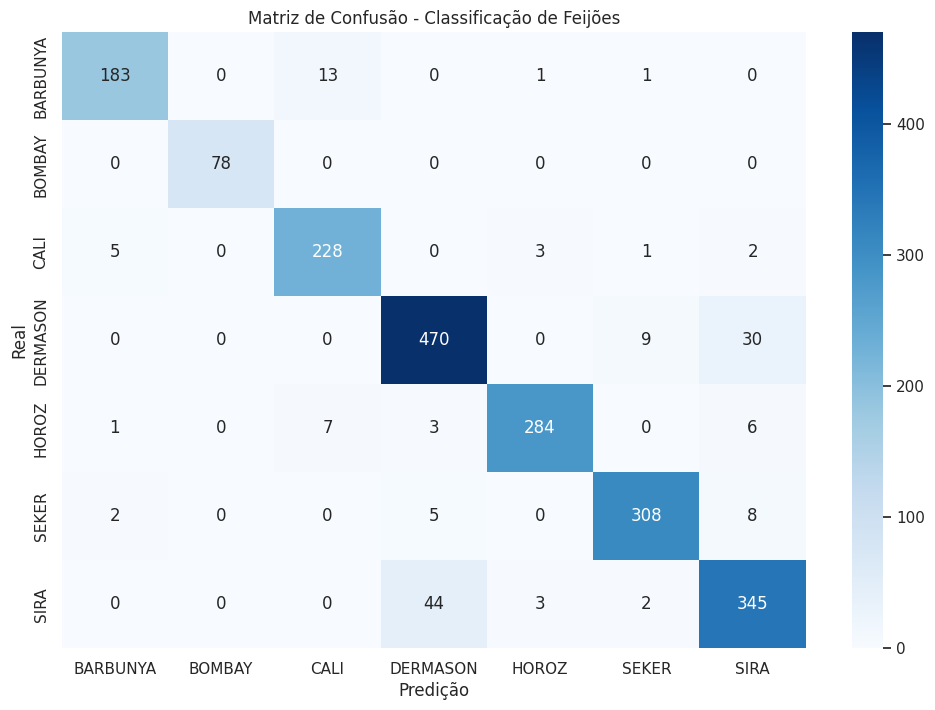

In [8]:
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão - Classificação de Feijões')
plt.xlabel('Predição')
plt.ylabel('Real')
plt.show()